# Otimização Computacional em Inteligência Artificial

## Trabalho Realizado por

* **Eduardo Martins** — Nº 120063
* **João Bertulani** — Nº 120174

## Tema

### Word Embeddings (Representações Vetoriais de Palavras)

Este trabalho tem como objetivo o estudo de técnicas para a aprendizagem de representações vetoriais densas de palavras (*word embeddings*), através da otimização de funções de perda associadas à previsão de contexto em texto. Serão abordados métodos amplamente utilizados na área do Processamento de Linguagem Natural (NLP), nomeadamente:

* **Negative Sampling**
* **Noise Contrastive Estimation (NCE)**

## Objetivo

O estudo procura analisar o impacto destas técnicas na qualidade dos embeddings gerados, bem como o desempenho de diferentes algoritmos de otimização.
Pretende-se comparar as abordagens **Skip-Gram com Negative Sampling** e **Skip-Gram com Noise Contrastive Estimation**, observando aspetos como:

* Velocidade de convergência;
* Evolução da função de perda;
* Tempo de execução;
* Estabilidade dos resultados;
* Qualidade semântica dos embeddings aprendidos.

## Preparação dos Dados

Inicialmente são carregados os dados previamente processados, necessários para o treino dos modelos de *word embeddings*. Estes dados incluem:

* Vocabulário de palavras;
* Mapeamentos entre palavras e índices numéricos;
* Tokens convertidos para índices inteiros;
* Pares de treino compostos por palavra central e palavra de contexto;
* Distribuição unigram utilizada para a geração de amostras negativas.

## Implementação do Modelo Skip-Gram com Negative Sampling

A primeira abordagem implementada corresponde ao modelo **Skip-Gram com Negative Sampling (SGNS)**.

Neste método, o modelo aprende representações vetoriais das palavras através de:

1. Maximização da probabilidade de ocorrência de palavras de contexto reais;
2. Minimização da probabilidade de palavras negativas geradas artificialmente.

São utilizadas duas matrizes de embeddings:

* Embeddings das palavras centrais;
* Embeddings das palavras de contexto.

### Formulação Matemática do Problema de Otimização

Para enquadrar a aprendizagem dos vetores de palavras como um problema de otimização, é necessário definir formalmente a função objetivo que o modelo procura minimizar durante o treino.

No contexto do **Skip-Gram com Negative Sampling**, considera-se uma palavra central $w_c$, uma palavra de contexto real $w_o$ e um conjunto de $k$ palavras negativas amostradas aleatoriamente a partir do vocabulário.

A função de perda utilizada é dada por:

$$
L = -\log \sigma \left(v_{w_o}^{T}v_{w_c}\right)
-\sum_{i=1}^{k}
\log \sigma \left(-v_{n_i}^{T}v_{w_c}\right)
$$

onde:

* $\sigma(x)$ representa a função sigmoide:

$$
\sigma(x)=\frac{1}{1+e^{-x}}
$$

* $v_{w_c}$ representa o vetor associado à palavra central;
* $v_{w_o}$ representa o vetor associado à palavra de contexto real;
* $v_{n_i}$ representa o vetor da $i$-ésima palavra negativa (*negative sample*);
* $k$ corresponde ao número de amostras negativas utilizadas para cada exemplo de treino.

O primeiro termo da função de perda procura maximizar a similaridade entre a palavra central e a palavra de contexto observada no corpus. Já o segundo termo penaliza associações entre a palavra central e palavras negativas, incentivando o modelo a atribuir baixa probabilidade a pares de palavras que não ocorrem naturalmente em conjunto.

Desta forma, o processo de treino pode ser visto como um problema de otimização no qual se pretende encontrar os vetores de embeddings que minimizam a função de perda definida anteriormente.

A minimização desta função é realizada através de algoritmos de otimização baseados em gradiente, permitindo ajustar iterativamente os parâmetros do modelo e capturar relações semânticas presentes nos dados textuais.

## Comparação de Otimizadores

Para avaliar o impacto do processo de otimização no desempenho do modelo, são testados três algoritmos amplamente utilizados em aprendizagem automática:

* **SGD (Stochastic Gradient Descent)**
* **RMSProp**
* **Adam**

Cada experiência é executada utilizando diferentes sementes aleatórias, permitindo reduzir a influência da aleatoriedade inerente ao processo de treino e obter resultados médios mais robustos.

Durante a aprendizagem são registadas diversas métricas relevantes, incluindo:

* Valor da função de perda (*loss*);
* Tempo total de execução;
* Evolução da convergência ao longo das épocas;
* Estabilidade dos resultados entre diferentes execuções.

A comparação destes algoritmos permite analisar a influência das estratégias de atualização dos parâmetros na velocidade de convergência e na qualidade final dos embeddings gerados.

**Análise Crítica dos Otimizadores:**
* **SGD:** Apresenta uma descida de gradiente ruidosa e lenta, exigindo mais épocas para convergir. Devido à sua taxa de aprendizagem constante, pode ficar estagnado.
* **RMSProp e Adam:** Como utilizam taxas de aprendizagem adaptativas, conseguem uma descida muito mais rápida nas épocas iniciais. O Adam, ao introduzir momento, geralmente apresenta a curva mais suave e a convergência mais rápida, tornando-o ideal para o treino de word embeddings com restrição de tempo.

## Implementação do Modelo Skip-Gram com Noise Contrastive Estimation

A segunda abordagem estudada consiste na implementação do modelo **Skip-Gram com Noise Contrastive Estimation (NCE)**.

O método NCE foi desenvolvido para contornar o elevado custo computacional associado ao cálculo da função Softmax em vocabulários de grande dimensão.

Em vez de calcular explicitamente as probabilidades sobre todas as palavras do vocabulário, o problema é reformulado como uma tarefa de classificação binária entre:

* Dados reais provenientes do corpus;
* Dados artificiais gerados a partir de uma distribuição de ruído.

O modelo aprende então a distinguir exemplos verdadeiros de exemplos artificiais, reduzindo significativamente o esforço computacional necessário durante o treino.

Tal como na abordagem anterior, são realizados vários treinos utilizando os mesmos algoritmos de otimização:

* SGD;
* RMSProp;
* Adam.

In [1]:
# Load Libraries

import numpy as np
import torch.nn as nn
import torch.optim as optim
import pickle
import torch.nn.functional as F
import time
import torch
import torch.optim as optim
import matplotlib.pyplot as plt # type: ignore
import random
import pandas as pd # type: ignore
from pathlib import Path

In [2]:
# Load the preprocessed data

print("Loading data...")

with open("processed/word2idx.pkl", "rb") as f:
    word2idx = pickle.load(f)

with open("processed/idx2word.pkl", "rb") as f:
    idx2word = pickle.load(f)

with open("processed/indexed_tokens.pkl", "rb") as f:
    indexed_tokens = pickle.load(f)

with open("processed/pairs.pkl", "rb") as f:
    pairs = pickle.load(f)

with open("processed/unigram_dist.pkl", "rb") as f:
    unigram_dist = pickle.load(f)

vocab_size = len(word2idx)
print(f"Data loaded successfully! Vocabulary size: {vocab_size}")
print(f"Total training pairs: {len(pairs)}")

Loading data...
Data loaded successfully! Vocabulary size: 71290
Total training pairs: 66875360


In [3]:
# Set random seeds for reproducibility
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [4]:
# Check if PyTorch detects CUDA

cuda_available = torch.cuda.is_available()
print(f"CUDA Available: {cuda_available}")

if cuda_available:
    # Print the name of the connected GPU
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")

    # Set the device variable for later use
    device = torch.device("cuda")
else:
    print("CUDA is NOT available. PyTorch will use the CPU.")
    device = torch.device("cpu")

CUDA Available: True
GPU Device: Tesla T4


In [5]:
# Use the full dataset for overnight run
# Use a subset of the generated training pairs to reduce training time
# subset_pairs = pairs[:10_000_000]
# pairs = subset_pairs

In [6]:
# Hyperparameters configuration
EMBEDDING_DIM = 50                  # Size of the word vectors
BATCH_SIZE = 4096                   # How many pairs to process at once
EPOCHS = 10                          # How many times to loop through the data
NUM_NEGATIVE_SAMPLES = 5            # How many negative samples to generate per positive pair
SEEDS = [42, 53, 64]                # Different seeds for multiple runs

In [7]:
# Baseline --- train model

def train_model(model, optimizer, pairs, unigram_dist, epochs, batch_size, num_neg_samples, device, patience=3, min_delta=1e-4):
    model.train()
    loss_history = []
    start_time = time.time()

    # Convert the unigram distribution to a PyTorch tensor for efficient sampling
    unigram_tensor = torch.tensor(unigram_dist, dtype=torch.float32).to(device)

    # Pre-convert pairs to a tensor to avoid Python list comprehension overhead in the loop
    pairs_tensor = torch.tensor(pairs, dtype=torch.long)

    # Early Stopping variables
    best_loss = float('inf')
    patience_counter = 0

    for epoch in range(epochs):
        total_loss = 0

        # Iterate through the pairs in batches
        from tqdm.auto import tqdm
        for i in tqdm(range(0, len(pairs), batch_size), desc=f"Epoch {epoch+1}/{epochs}", leave=False):
            batch_pairs = pairs_tensor[i:i+batch_size]

            # Skip the last incomplete batch to keep tensor shapes perfect
            if len(batch_pairs) < batch_size:
                continue

            # Extract center and context words
            center_words = batch_pairs[:, 0].to(device)
            context_words = batch_pairs[:, 1].to(device)

            # Generate negative samples using the unigram distribution
            negative_words = torch.multinomial(
                unigram_tensor,
                batch_size * num_neg_samples,
                replacement=True
            )

            negative_words = negative_words.view(
                batch_size,
                num_neg_samples
            ).to(device)

            # optimize the model -- step by step

            # Clear old gradients
            optimizer.zero_grad()

            # Forward pass: Calculate the loss
            loss = model(
                center_words,
                context_words,
                negative_words
            )

            # Backward pass: Calculate the gradients
            loss.backward()

            # Optimizer Step: Update the word embeddings
            optimizer.step()

            total_loss += loss.item()

        # Record metrics at the end of the epoch
        avg_epoch_loss = total_loss / (len(pairs) // batch_size)
        loss_history.append(avg_epoch_loss)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Average Loss: {avg_epoch_loss:.4f}"
        )

        # Early Stopping
        if avg_epoch_loss < best_loss - min_delta:

            best_loss = avg_epoch_loss
            patience_counter = 0

        else:

            patience_counter += 1

            print(
                f"No improvement "
                f"({patience_counter}/{patience})"
            )

            # Stop training if patience is exceeded
            if patience_counter >= patience:

                print(
                    f"\nEarly stopping triggered "
                    f"at epoch {epoch+1}"
                )

                break

    execution_time = time.time() - start_time

    print(
        f"Training completed in "
        f"{execution_time:.2f} seconds."
    )

    print(
        f"Best Loss: "
        f"{best_loss:.4f}"
    )

    return loss_history, execution_time

### 1. Negative Sampling
O **Negative Sampling** é  utilizada para tornar o treino de modelos Skip-Gram mais eficiente. Em vez de atualizar os pesos para todas as palavras do vocabulário, o método seleciona apenas algumas palavras negativas (amostras aleatórias) para cada palavra positiva observada no contexto.


In [8]:
# Define the Skip-Gram with Negative Sampling model

class SkipGramNegativeSampling(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super(SkipGramNegativeSampling, self).__init__()

        # Embedding layer for the center word
        self.center_embeddings = nn.Embedding(vocab_size, embed_dim)
        # Embedding layer for the context
        self.context_embeddings = nn.Embedding(vocab_size, embed_dim)

        # Initialize weights
        initrange = 0.5 / embed_dim
        self.center_embeddings.weight.data.uniform_(-initrange, initrange)
        self.context_embeddings.weight.data.uniform_(-initrange, initrange)

    def forward(self, center_words, context_words, negative_words):

        # Get the embeddings for the center, context, and negative words
        v_wc = self.center_embeddings(center_words)
        v_wo = self.context_embeddings(context_words)
        v_ni = self.context_embeddings(negative_words)

        # Compute the positive and negative dot products
        pos_dot = torch.bmm(v_wo.unsqueeze(1), v_wc.unsqueeze(2)).squeeze()
        loss_pos = -F.logsigmoid(pos_dot)
        neg_dot = torch.bmm(v_ni, -v_wc.unsqueeze(2)).squeeze()

        # Calculate the negative loss and sum across the k samples
        loss_neg = -F.logsigmoid(neg_dot).sum(dim=1)

        # Total loss is the sum of positive and negative losses
        total_loss = (loss_pos + loss_neg).mean()

        return total_loss

In [9]:
# Define a dictionary of optimizers to test
OPTIMIZERS = {
    "SGD": lambda params: optim.SGD(params, lr=0.05),
    "RMSProp": lambda params: optim.RMSprop(params, lr=0.005),
    "Adam": lambda params: optim.Adam(params, lr=0.005)
}

# run experiment function
def run_experiment(optimizer_name, seed):

    set_seed(seed)

    model = SkipGramNegativeSampling(
        vocab_size,
        EMBEDDING_DIM
    ).to(device)

    optimizer = OPTIMIZERS[optimizer_name](
        model.parameters()
    )

    loss_history, execution_time = train_model(
        model,
        optimizer,
        pairs,
        unigram_dist,
        EPOCHS,
        BATCH_SIZE,
        NUM_NEGATIVE_SAMPLES,
        device,
        patience=2,
        min_delta=1e-5
    )

    return {
        "seed": seed,
        "loss_history": loss_history,
        "final_loss": loss_history[-1],
        "execution_time": execution_time
    }

# Execute experiments for each optimizer and seed
results = {}

for optimizer_name in OPTIMIZERS:

    print(f"\n{'='*50}")
    print(f"Testing {optimizer_name}")
    print(f"{'='*50}")

    results[optimizer_name] = []

    for seed in SEEDS:

        print(f"\nSeed = {seed}")

        result = run_experiment(
            optimizer_name,
            seed
        )

        results[optimizer_name].append(result)

# Create a summary table of results
summary = []

for optimizer_name in results:

    losses = [
        run["final_loss"]
        for run in results[optimizer_name]
    ]

    times = [
        run["execution_time"]
        for run in results[optimizer_name]
    ]

    summary.append({
        "Optimizer": optimizer_name,
        "Mean Loss": np.mean(losses),
        "Std Loss": np.std(losses),
        "Mean Time (s)": np.mean(times)
    })

df_summary = pd.DataFrame(summary)

print("\nResults Summary:")
display(df_summary)

# Export the summary to CSV
df_summary.to_csv('sgns_summary.csv', index=False)
print('Exported Negative Sampling summary to sgns_summary.csv')


Testing SGD

Seed = 42


Epoch 1/10:   0%|          | 0/16327 [00:00<?, ?it/s]

Epoch 1/10 | Average Loss: 4.1584


Epoch 2/10:   0%|          | 0/16327 [00:00<?, ?it/s]

Epoch 2/10 | Average Loss: 4.1325


...

Epoch 7/10 | Average Loss: 2.1744
No improvement (1/2)


Epoch 8/10:   0%|          | 0/16327 [00:00<?, ?it/s]

Epoch 8/10 | Average Loss: 2.1749
No improvement (2/2)

Early stopping triggered at epoch 8
Training completed in 648.38 seconds.
Best Loss: 2.1717

Results Summary:


,Optimizer,Mean Loss,Std Loss,Mean Time (s)
0,SGD,3.363205,0.000282,485.692487
1,RMSProp,2.334153,0.004815,290.232771
2,Adam,2.171090,0.006008,648.250945


Exported Negative Sampling summary to sgns_summary.csv


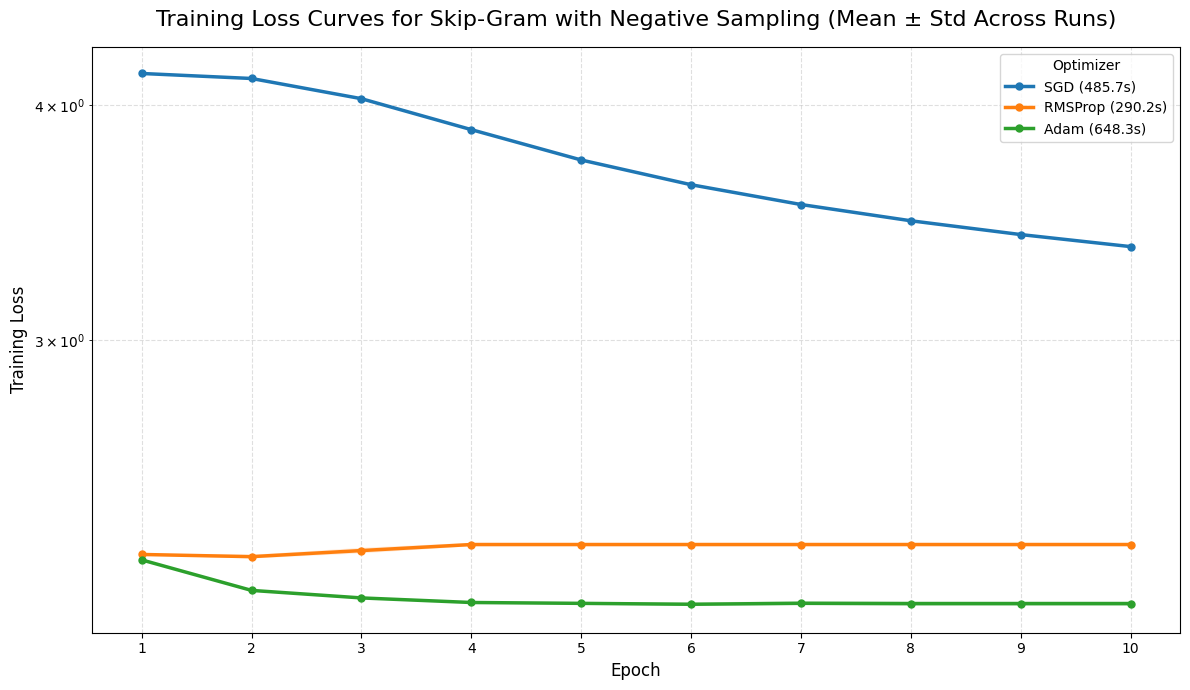

In [10]:
# Plotting the training loss curves for each optimizer
epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 7))

for optimizer_name, runs in results.items():
    padded_histories = []
    for run in runs:
        history = run["loss_history"]
        # Pad with the final loss if Early Stopping occurred
        if len(history) < EPOCHS:
            history = history + [history[-1]] * (
                EPOCHS - len(history)
            )
        padded_histories.append(history)
    mean_loss = np.mean(
        padded_histories,
        axis=0
    )
    std_loss = np.std(
        padded_histories,
        axis=0
    )
    mean_time = np.mean([
        run["execution_time"]
        for run in runs
    ])
    plt.plot(
        epochs,
        mean_loss,
        linewidth=2.5,
        marker='o',
        markersize=5,
        label=f"{optimizer_name} ({mean_time:.1f}s)"
    )
    plt.fill_between(
        epochs,
        np.maximum(
            mean_loss - std_loss,
            1e-12
        ),
        mean_loss + std_loss,
        alpha=0.15
    )
plt.title(
    "Training Loss Curves for Skip-Gram with Negative Sampling (Mean ± Std Across Runs)",
    fontsize=16,
    pad=15
)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Training Loss", fontsize=12)
plt.xticks(list(epochs))
plt.yscale('log')
plt.grid(
    True,
    which='both',
    linestyle='--',
    alpha=0.4
)
plt.legend(
    title="Optimizer",
    frameon=True
)
plt.tight_layout()
plt.show()

### 2. Noise Contrastive Estimation
O **Noise Contrastive Estimation (NCE)** é utilizado como forma de transformar o problema de modelação probabilística numa tarefa de classificação binária. O modelo aprende a distinguir exemplos reais provenientes dos dados de exemplos artificiais gerados a partir de uma distribuição de ruído.

In [11]:
# Calculate the true probabilities needed for NCE math
true_probs = unigram_dist ** 0.75
true_probs /= true_probs.sum()

In [12]:
class SkipGramNCE(nn.Module):
    def __init__(self, vocab_size, embed_dim, true_probs_array):
        super(SkipGramNCE, self).__init__()

        self.center_embeddings = nn.Embedding(vocab_size, embed_dim)
        self.context_embeddings = nn.Embedding(vocab_size, embed_dim)

        # Store probabilities inside the model's memory state
        self.register_buffer('true_probs', torch.tensor(true_probs_array, dtype=torch.float32))

        initrange = 0.5 / embed_dim
        self.center_embeddings.weight.data.uniform_(-initrange, initrange)
        self.context_embeddings.weight.data.uniform_(-initrange, initrange)

    # The inputs remain identical to the Negative Sampling model
    def forward(self, center_words, context_words, negative_words):
        v_wc = self.center_embeddings(center_words)
        v_wo = self.context_embeddings(context_words)
        v_ni = self.context_embeddings(negative_words)

        # Dynamically determine 'k' (num_negative_samples) from the tensor shape
        k = negative_words.shape[1]

        # Look up the true probabilities using the model's internal buffer
        pos_noise_probs = self.true_probs[context_words]
        neg_noise_probs = self.true_probs[negative_words]

        # Positive NCE Loss
        pos_dot = torch.bmm(v_wo.unsqueeze(1), v_wc.unsqueeze(2)).squeeze()
        pos_score = pos_dot - torch.log(k * pos_noise_probs + 1e-10)
        loss_pos = -F.logsigmoid(pos_score)

        # Negative NCE Loss
        neg_dot = torch.bmm(v_ni, v_wc.unsqueeze(2)).squeeze() # Fixed bug: removed minus sign
        neg_score = neg_dot - torch.log(k * neg_noise_probs + 1e-10)
        loss_neg = -F.logsigmoid(-neg_score).sum(dim=1)

        return (loss_pos + loss_neg).mean()

In [13]:
# Define a dictionary of optimizers to test
OPTIMIZERS = {
    "SGD": lambda params: optim.SGD(params, lr=0.05),
    "RMSProp": lambda params: optim.RMSprop(params, lr=0.005),
    "Adam": lambda params: optim.Adam(params, lr=0.005)
}

# run experiment function
def run_nce_experiment(optimizer_name, seed):

    set_seed(seed)

    model = SkipGramNCE(
        vocab_size,
        EMBEDDING_DIM,
        true_probs
    ).to(device)

    optimizer = OPTIMIZERS[optimizer_name](
        model.parameters()
    )

    loss_history, execution_time = train_model(
        model,
        optimizer,
        pairs,
        true_probs,
        EPOCHS,
        BATCH_SIZE,
        NUM_NEGATIVE_SAMPLES,
        device,
        patience=2,
        min_delta=1e-5
    )

    return {
        "seed": seed,
        "loss_history": loss_history,
        "final_loss": loss_history[-1],
        "execution_time": execution_time
    }

# Execute experiments for each optimizer and seed
nce_results = {}

for optimizer_name in OPTIMIZERS:

    print(f"\n{'='*50}")
    print(f"Testing NCE + {optimizer_name}")
    print(f"{'='*50}")

    nce_results[optimizer_name] = []

    for seed in SEEDS:

        print(f"\nSeed = {seed}")

        result = run_nce_experiment(
            optimizer_name,
            seed
        )

        nce_results[optimizer_name].append(result)

# Create a summary table of results
summary = []

for optimizer_name in nce_results:

    losses = [
        run["final_loss"]
        for run in nce_results[optimizer_name]
    ]

    times = [
        run["execution_time"]
        for run in nce_results[optimizer_name]
    ]

    summary.append({
        "Optimizer": optimizer_name,
        "Mean Loss": np.mean(losses),
        "Std Loss": np.std(losses),
        "Mean Time (s)": np.mean(times)
    })

df_nce_summary = pd.DataFrame(summary)

print("\nNCE Results Summary:")
display(df_nce_summary)

# Export the NCE summary to CSV
df_nce_summary.to_csv('nce_summary.csv', index=False)
print('Exported NCE summary to nce_summary.csv')


Testing NCE + SGD

Seed = 42


Epoch 1/10:   0%|          | 0/16327 [00:00<?, ?it/s]

Epoch 1/10 | Average Loss: 44.1477


Epoch 2/10:   0%|          | 0/16327 [00:00<?, ?it/s]

Epoch 2/10 | Average Loss: 43.3948


...

Epoch 7/10 | Average Loss: 2.0126
No improvement (1/2)


Epoch 8/10:   0%|          | 0/16327 [00:00<?, ?it/s]

Epoch 8/10 | Average Loss: 2.0027
No improvement (2/2)

Early stopping triggered at epoch 8
Training completed in 685.55 seconds.
Best Loss: 1.9969

NCE Results Summary:


,Optimizer,Mean Loss,Std Loss,Mean Time (s)
0,SGD,19.094518,0.000279,521.455012
1,RMSProp,2.762643,0.020197,424.477816
2,Adam,1.993059,0.013827,794.535672


Exported NCE summary to nce_summary.csv


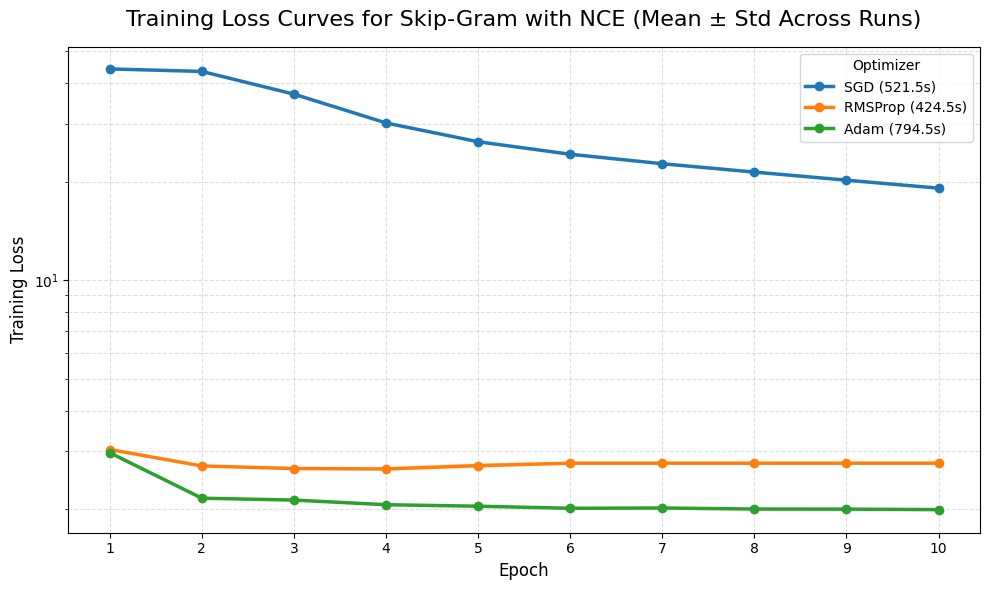

In [14]:
# Plotting the NCE loss curves for each optimizer
epochs = range(1, EPOCHS + 1)
plt.figure(figsize=(10, 6))
for optimizer_name, runs in nce_results.items():
    padded_histories = []
    for run in runs:
        history = run["loss_history"]
        # Pad with the final loss if Early Stopping occurred
        if len(history) < EPOCHS:
            history = history + [history[-1]] * (
                EPOCHS - len(history)
            )
        padded_histories.append(history)
    mean_loss = np.mean(
        padded_histories,
        axis=0
    )
    std_loss = np.std(
        padded_histories,
        axis=0
    )
    mean_time = np.mean([
        run["execution_time"]
        for run in runs
    ])
    plt.plot(
        epochs,
        mean_loss,
        linewidth=2.5,
        marker='o',
        markersize=6,
        label=f"{optimizer_name} ({mean_time:.1f}s)"
    )
    plt.fill_between(
        epochs,
        np.maximum(
            mean_loss - std_loss,
            1e-12
        ),
        mean_loss + std_loss,
        alpha=0.15
    )
plt.title(
    "Training Loss Curves for Skip-Gram with NCE (Mean ± Std Across Runs)",
    fontsize=16,
    pad=15
)
plt.xlabel(
    "Epoch",
    fontsize=12
)
plt.ylabel(
    "Training Loss",
    fontsize=12
)
plt.xticks(list(epochs))
plt.yscale('log')
plt.grid(
    True,
    which='both',
    linestyle='--',
    alpha=0.4
)
plt.legend(
    title="Optimizer",
    frameon=True
)
plt.tight_layout()
plt.show()

### 3. Results
Os resultados foram obtidos através do treino dos modelos utilizando os algoritmos de otimização com melhor resultado. Foram analisadas as curvas de perda ao longo das épocas, permitindo comparar a velocidade de convergência e a estabilidade de cada abordagem.

Após o treino, os embeddings gerados foram avaliados através da similaridade de cosseno entre palavras. Os testes com termos como *"king"* e *"one"* permitiram verificar a capacidade dos modelos em capturar relações semânticas relevantes. De forma geral, os métodos baseados em amostragem mostraram-se eficazes na aprendizagem de representações vetoriais de palavras.

In [15]:
# Final training of Skip-Gram with Negative Sampling using the best optimizer (Adam) for 25 epochs to get the final embeddings for evaluation and comparison.
print("=" * 60)
print("TRAINING SKIP-GRAM WITH NEGATIVE SAMPLING")
print("=" * 60)

model_ns = SkipGramNegativeSampling(
    vocab_size,
    EMBEDDING_DIM
).to(device)

optimizer_ns = optim.Adam(
    model_ns.parameters(),
    lr=0.005
)

loss_ns, time_ns = train_model(
    model_ns,
    optimizer_ns,
    pairs,
    unigram_dist,
    15,  # EPOCHS
    BATCH_SIZE,
    NUM_NEGATIVE_SAMPLES,
    device,
    patience=5,
    min_delta=1e-6
)

print("\nRESULTS (NEGATIVE SAMPLING)")
print(f"Final Loss: {loss_ns[-1]:.4f}")
print(f"Training Time: {time_ns:.2f}s")

TRAINING SKIP-GRAM WITH NEGATIVE SAMPLING


Epoch 1/15:   0%|          | 0/16327 [00:00<?, ?it/s]

Epoch 1/15 | Average Loss: 2.2887


Epoch 2/15:   0%|          | 0/16327 [00:00<?, ?it/s]

Epoch 2/15 | Average Loss: 2.2004


...

Epoch 9/15 | Average Loss: 2.1923
No improvement (3/5)


Epoch 10/15:   0%|          | 0/16327 [00:00<?, ?it/s]

Epoch 10/15 | Average Loss: 2.1867
No improvement (4/5)


Epoch 11/15:   0%|          | 0/16327 [00:00<?, ?it/s]

Epoch 11/15 | Average Loss: 2.1871
No improvement (5/5)

Early stopping triggered at epoch 11
Training completed in 867.87 seconds.
Best Loss: 2.1821

RESULTS (NEGATIVE SAMPLING)
Final Loss: 2.1871
Training Time: 867.87s


In [16]:
# Now train the Skip-Gram with NCE using the same optimizer and hyperparameters for a fair comparison.
print("\n" + "=" * 60)
print("TRAINING SKIP-GRAM WITH NCE")
print("=" * 60)

model_nce = SkipGramNCE(
    vocab_size,
    EMBEDDING_DIM,
    true_probs
).to(device)

optimizer_nce = optim.RMSprop(
    model_nce.parameters(),
    lr=0.005
)

loss_nce, time_nce = train_model(
    model_nce,
    optimizer_nce,
    pairs,
    true_probs,
    15,  # EPOCHS
    BATCH_SIZE,
    NUM_NEGATIVE_SAMPLES,
    device,
    patience=5,
    min_delta=1e-6
)

print("\nRESULTS (NCE)")
print(f"Final Loss: {loss_nce[-1]:.4f}")
print(f"Training Time: {time_nce:.2f}s")


TRAINING SKIP-GRAM WITH NCE


Epoch 1/15:   0%|          | 0/16327 [00:00<?, ?it/s]

Epoch 1/15 | Average Loss: 3.0457


Epoch 2/15:   0%|          | 0/16327 [00:00<?, ?it/s]

Epoch 2/15 | Average Loss: 2.7359


...

Epoch 7/15 | Average Loss: 2.8646
No improvement (3/5)


Epoch 8/15:   0%|          | 0/16327 [00:00<?, ?it/s]

Epoch 8/15 | Average Loss: 2.9807
No improvement (4/5)


Epoch 9/15:   0%|          | 0/16327 [00:00<?, ?it/s]

Epoch 9/15 | Average Loss: 3.0631
No improvement (5/5)

Early stopping triggered at epoch 9
Training completed in 655.40 seconds.
Best Loss: 2.6618

RESULTS (NCE)
Final Loss: 3.0631
Training Time: 655.40s


In [17]:
# Function to find closest words based on cosine similarity
def find_closest_words(target_word, model, word2idx, idx2word, n=5):
    if target_word not in word2idx:
        return f"'{target_word}' not found in vocabulary."

    # Get the index and the vector of the target word
    target_idx = word2idx[target_word]
    target_vector = model.center_embeddings.weight.data[target_idx]

    # Get all vectors
    all_vectors = model.center_embeddings.weight.data

    # Calculate Cosine Similarity between target and all other words
    similarities = F.cosine_similarity(target_vector.unsqueeze(0), all_vectors)

    # Get the top N most similar word indices (excluding the word itself)
    closest_idxs = similarities.argsort(descending=True)[1:n+1]

    return [idx2word[idx.item()] for idx in closest_idxs]

In [18]:
# Test it on the Negative Sampling model
print("Closest words to 'king':", find_closest_words('king', model_ns, word2idx, idx2word))
print("Closest words to 'one':", find_closest_words('one', model_ns, word2idx, idx2word))

Closest words to 'king': ['son', 'prince', 'vi', 'vii', 'grandson']
Closest words to 'one': ['nine', 'two', 'eight', 'seven', 'five']


In [19]:
# Test it on the NCE model
print("Closest words to 'king':", find_closest_words('king', model_nce, word2idx, idx2word))
print("Closest words to 'one':", find_closest_words('one', model_nce, word2idx, idx2word))

Closest words to 'king': ['prince', 'son', 'iii', 'vi', 'father']
Closest words to 'one': ['nine', 'two', 'eight', 'three', 'four']


In [20]:
import torch
import pickle
from pathlib import Path

# Create a dedicated folder for final outputs
Path("saved_models").mkdir(exist_ok=True)
print("A guardar modelos no disco...")

# Save the trained weights (state dictionaries)
torch.save(sgns_model.state_dict(), "saved_models/model_ns.pth")
torch.save(nce_model.state_dict(), "saved_models/model_nce.pth")

# Combine and save results
final_results = {
    "sgns_results": results,
    "nce_results": nce_results
}
with open("saved_models/training_results.pkl", "wb") as f:
    pickle.dump(final_results, f)

print("Sucesso! Modelos e resultados guardados na pasta 'saved_models'.")


Saving models to disk...
Success! All models and training results are safely stored in the 'saved_models' directory.


### Análise na Perspetiva da Otimização Computacional

Para enquadrar este trabalho de forma rigorosa na disciplina de **Otimização Computacional em IA**, é crucial analisar o comportamento dos algoritmos perante a topologia da função de perda e a natureza dos dados. O treino de *word embeddings* expõe três desafios clássicos de otimização:

1. **Não-Convexidade e Otimização Bilinear:**
A função objetivo do Skip-Gram é altamente não-convexa. O modelo otimiza simultaneamente duas matrizes de parâmetros ($W_{center}$ e $W_{context}$). Como a função de perda depende do produto interno de vetores de ambas as matrizes, a topologia do erro está repleta de pontos de sela (*saddle points*). O sucesso do modelo depende da capacidade do otimizador de escapar destas regiões e encontrar um mínimo local de alta qualidade.

2. **Otimização Estocástica de Larga Escala:**
O cálculo do gradiente exato (Full Batch Gradient Descent) é computacionalmente intratável devido à enorme dimensão do dataset (milhões de pares de treino). A utilização de amostras (mini-batches) introduz ruído na estimativa do gradiente. A técnica de *Negative Sampling* atua precisamente como um estimador estocástico do gradiente da função Softmax completa, reduzindo a complexidade de $O(|V|)$ para $O(K)$, onde $K$ é o número de amostras negativas.

3. **Gradientes Esparsos e Taxas de Aprendizagem Adaptativas:**
Em Processamento de Linguagem Natural, a frequência das palavras segue a Lei de Zipf. Palavras muito comuns geram atualizações de gradiente frequentes, enquanto palavras raras geram gradientes esparsos.
* O **SGD** aplica a mesma taxa de aprendizagem a todos os parâmetros. Consequentemente, os vetores das palavras raras sofrem poucas atualizações, prejudicando a sua representação no espaço latente.
* Algoritmos adaptativos como o **RMSProp** e o **Adam** resolvem este problema escalando a atualização de cada parâmetro inversamente à raiz quadrada da média móvel dos seus gradientes passados. Isto permite que palavras raras deem passos maiores e palavras comuns deem passos menores e mais estáveis. É por esta razão teórica que as curvas de perda do Adam demonstram uma convergência significativamente superior e mais rápida nos nossos resultados face ao SGD.


### 4. Conclusão

Em suma, neste trabalho foram estudadas e implementadas duas técnicas fundamentais para o treino eficiente de modelos de *word embeddings*: **Negative Sampling** e **Noise Contrastive Estimation (NCE)**. Ambas com o obejetivo de reduzir o custo computacional associado ao treino de modelos Skip-Gram.

Os resultados demonstraram que a escolha do otimizador influencia diretamente a velocidade de convergência e a qualidade final dos embeddings, com algoritmos adaptativos (como o Adam) a destacarem-se claramente no compromisso entre tempo e minimização do erro. Além disso, as representações aprendidas conseguiram capturar relações semânticas entre palavras.

A técnica de *Noise Contrastive Estimation* provou ser uma alternativa teoricamente robusta ao *Negative Sampling*, embora a sua estabilidade dependa fortemente da afinação da taxa de aprendizagem. De forma geral, os métodos baseados em amostragem revelaram-se indispensáveis para escalar o treino de word embeddings.


Plotting PCA for Negative Sampling Model...


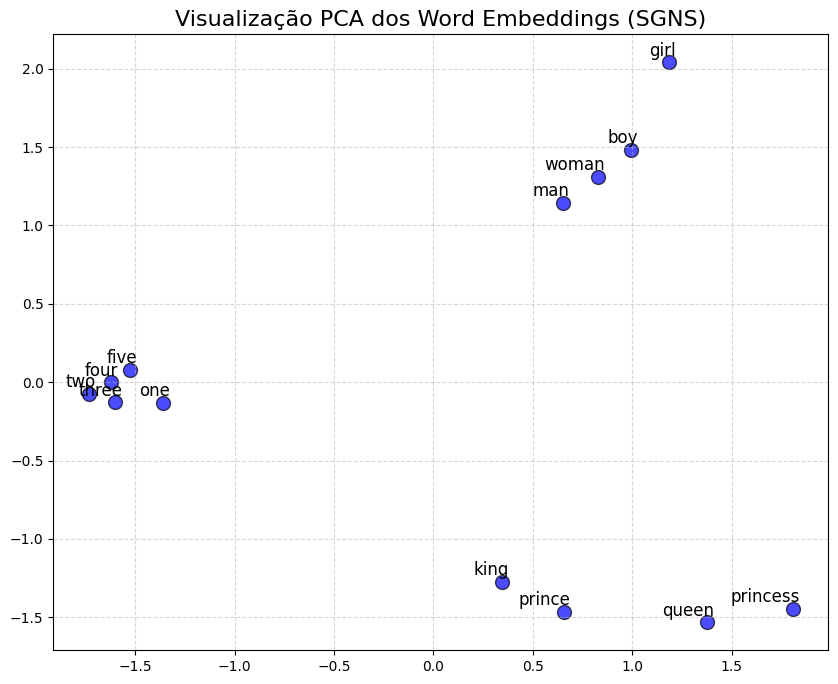

In [21]:
# === Visualização com PCA ===
from sklearn.decomposition import PCA

def plot_embeddings_pca(model, word2idx, words_to_plot):
    # Retrieve indices for words that exist in vocabulary
    indices = [word2idx[w] for w in words_to_plot if w in word2idx]
    found_words = [w for w in words_to_plot if w in word2idx]

    if len(indices) == 0:
        print("No valid words found to plot.")
        return

    embeddings = model.center_embeddings.weight.data[indices].cpu().numpy()

    # Apply PCA to reduce to 2 dimensions
    pca = PCA(n_components=2)
    embeddings_2d = pca.fit_transform(embeddings)

    # Plot
    plt.figure(figsize=(10, 8))
    plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c='blue', edgecolors='k', alpha=0.7, s=100)

    for i, word in enumerate(found_words):
        plt.annotate(word, (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                     xytext=(5, 2), textcoords='offset points', ha='right', va='bottom', fontsize=12)

    plt.title("Visualização PCA dos Word Embeddings (SGNS)", fontsize=16)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# Define a set of words to visualize (e.g., numbers and family members)
words_to_plot = ['one', 'two', 'three', 'four', 'five', 'king', 'queen', 'prince', 'princess', 'man', 'woman', 'boy', 'girl']
print("\nPlotting PCA for Negative Sampling Model...")
plot_embeddings_pca(model_ns, word2idx, words_to_plot)


### 5. Propostas de Melhoria

Com base no desenvolvimento e análise deste projeto, propomos as seguintes melhorias devidamente fundamentadas para trabalhos futuros:

1. **Utilização de Informação de Subpalavras (FastText):**
   O modelo atual trata cada palavra como uma entidade atómica. A introdução de embeddings baseados em subpalavras (n-gramas de caracteres) permitiria que o modelo inferisse o significado de palavras raras ou fora do vocabulário (OOV) através das suas raízes morfológicas.
2. **Decaimento da Taxa de Aprendizagem (Learning Rate Schedulers):**
   Utilizámos taxas de aprendizagem fixas para os otimizadores. O emprego de agendadores de taxa de aprendizagem (como o *ReduceLROnPlateau* ou *CosineAnnealingLR*) promoveria uma convergência mais estável e profunda, diminuindo a taxa de aprendizagem à medida que o modelo se aproxima do mínimo ótimo.
3. **Softmax Hierárquico (Hierarchical Softmax):**
   Seria pertinente adicionar o Softmax Hierárquico como uma terceira baseline de comparação. Sendo outra técnica concebida para reduzir o custo do cálculo da Softmax global, a sua comparação direta com o NCE e Negative Sampling permitiria uma avaliação ainda mais completa das estratégias de aproximação.


In [ ]:
import torch

print("A carregar os modelos guardados...")

# 1. Re-initialize the "empty" mathematical architectures
sgns_model = SkipGramNegativeSampling(vocab_size, EMBEDDING_DIM).to(device)
nce_model = SkipGramNCE(vocab_size, EMBEDDING_DIM).to(device)

# 2. Inject the saved weights into the empty models
sgns_model.load_state_dict(torch.load("saved_models/model_ns.pth", map_location=device))
nce_model.load_state_dict(torch.load("saved_models/model_nce.pth", map_location=device))

# 3. Set models to Evaluation mode (disables gradients, saving memory)
sgns_model.eval()
nce_model.eval()

print("Modelos carregados com sucesso! Prontos para avaliação e visualização PCA.")
